# Capstone — mirrors your deployed research paper

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/MansiNegi281/CapstoneFlyrankAI/blob/main/work/notebooks/capstone.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Question

*The research question and the decision it supports.*

Research question: Can a page's own performance history predict when it
needs a content refresh, before traffic loss becomes severe?

Decision this supports: which pages a content team reviews first each
cycle, out of far more pages than they have time to manually audit.

In [1]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
%pip install -q duckdb huggingface_hub

import duckdb
import pandas as pd
from getpass import getpass

hf_token = getpass("Paste your token here: ")

con = duckdb.connect()
con.sql(f"CREATE SECRET hf_secret (TYPE huggingface, TOKEN '{hf_token}')")
warehouse = "hf://datasets/FlyRank/internship-warehouse"

pd.set_option('display.max_colwidth', None)
print("Connected.")

Paste your token here: ··········
Connected.


## 2. Data

*Which release, which tables, date windows, what you excluded and why. Public-safe.*

Data: FlyRank internship warehouse (dim_content, fact_content_daily_performance),
hf://datasets/FlyRank/internship-warehouse. 90-day trailing performance
window, 30-day trend comparison, anchored to the latest available report
date. 401,259 content pages included after joining performance to content
metadata and filtering out deleted content (is_deleted = false). No client
names, domains, or private queries appear in this notebook or its outputs —
client_hash_id and content_hash_id are used only for grouping, never
displayed or used as features.

In [2]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
anchor = con.sql(f"""
    SELECT MAX(report_date) AS max_date
    FROM read_parquet('{warehouse}/fact_content_daily_performance/**/*.parquet')
""").df()
anchor_date = anchor["max_date"][0]
print("Anchor date:", anchor_date)

query = f"""
WITH perf_90d AS (
    SELECT
        content_hash_id,
        client_hash_id,
        SUM(gsc_impressions) AS impressions_90d,
        SUM(gsc_clicks) AS clicks_90d,
        SUM(ga4_sessions) AS sessions_90d,
        SUM(ga4_engaged_sessions) AS engaged_sessions_90d,
        SUM(scroll_events) AS scroll_events_90d,
        AVG(gsc_avg_position) AS avg_position
    FROM read_parquet('{warehouse}/fact_content_daily_performance/**/*.parquet')
    WHERE report_date > DATE '{anchor_date}' - INTERVAL 90 DAY
    GROUP BY content_hash_id, client_hash_id
),
trend_recent AS (
    SELECT content_hash_id, SUM(gsc_impressions) AS imp_last_30
    FROM read_parquet('{warehouse}/fact_content_daily_performance/**/*.parquet')
    WHERE report_date > DATE '{anchor_date}' - INTERVAL 30 DAY
    GROUP BY content_hash_id
),
trend_prev AS (
    SELECT content_hash_id, SUM(gsc_impressions) AS imp_prev_30
    FROM read_parquet('{warehouse}/fact_content_daily_performance/**/*.parquet')
    WHERE report_date > DATE '{anchor_date}' - INTERVAL 60 DAY
      AND report_date <= DATE '{anchor_date}' - INTERVAL 30 DAY
    GROUP BY content_hash_id
)
SELECT
    p.content_hash_id AS content_id,
    p.client_hash_id AS client_id,
    d.search_volume,
    p.clicks_90d / NULLIF(p.impressions_90d, 0) AS ctr,
    p.avg_position,
    p.engaged_sessions_90d / NULLIF(p.sessions_90d, 0) AS engagement_rate,
    p.scroll_events_90d / NULLIF(p.sessions_90d, 0) AS scroll_rate,
    DATE_DIFF('day', d.content_created_date, DATE '{anchor_date}') AS content_age_days,
    DATE_DIFF('day', d.content_updated_date, DATE '{anchor_date}') AS days_since_last_update,
    p.impressions_90d,
    p.sessions_90d,
    r.imp_last_30,
    pr.imp_prev_30,
    CASE
        WHEN pr.imp_prev_30 IS NULL OR pr.imp_prev_30 = 0 THEN 'new'
        WHEN (r.imp_last_30 - pr.imp_prev_30) / pr.imp_prev_30 < -0.10 THEN 'down'
        WHEN (r.imp_last_30 - pr.imp_prev_30) / pr.imp_prev_30 > 0.10 THEN 'up'
        ELSE 'stable'
    END AS trend_direction
FROM perf_90d p
JOIN read_parquet('{warehouse}/dim_content.parquet') d ON p.content_hash_id = d.content_hash_id
LEFT JOIN trend_recent r ON p.content_hash_id = r.content_hash_id
LEFT JOIN trend_prev pr ON p.content_hash_id = pr.content_hash_id
WHERE d.is_deleted = false
"""

df = con.sql(query).df()
print("Total pages:", df.shape[0])
print(df["trend_direction"].value_counts())

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Anchor date: 2026-06-30 00:00:00


FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

Total pages: 401259
trend_direction
down      178615
new       164234
up         42664
stable     15746
Name: count, dtype: int64


## 3. Methodology

*Assumptions, features, label definition, baseline, validation design, leakage checks.*

Task type: binary classification + ranking. Target: is_declining = 1 if
30-day impressions fell more than 10% vs. the prior 30 days, else 0 — an
observed-rule proxy, not a ground-truth outcome.

Features: search_volume, ctr, avg_position, engagement_rate, scroll_rate,
content_age_days, days_since_last_update, impressions_90d, sessions_90d.
All are knowable before prediction time.

Baseline: a hand-written weighted score (Week 4), precision 0.5723,
computed on the smaller anonymized starter dataset.

Validation design: client-grouped train/test split (not random) — no
client's pages appear in both train and test. Motivated by a concrete
finding in the Week 4 baseline queue, where 5 of the top 5 highest-scored
pages belonged to a single client.

Leakage check: correlation between every feature and the label, computed
directly below. Highest was avg_position at 0.351, well under a 0.9
leakage threshold. Neither trend_direction nor its source impression
values are used as features.

In [3]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
df["is_declining"] = (df["trend_direction"] == "down").astype(int)

feature_cols = ["search_volume", "ctr", "avg_position", "engagement_rate",
                 "scroll_rate", "content_age_days", "days_since_last_update",
                 "impressions_90d", "sessions_90d"]

X = df[feature_cols].fillna(0)
y = df["is_declining"]
groups = df["client_id"]

print(X.shape)
print(y.value_counts())

corr = X.corrwith(y).sort_values(key=abs, ascending=False)
print("\nLeakage check — correlation with label:")
print(corr)

(401259, 9)
is_declining
0    222644
1    178615
Name: count, dtype: int64

Leakage check — correlation with label:
avg_position              0.351390
content_age_days         -0.076228
impressions_90d           0.075861
scroll_rate               0.036804
ctr                       0.035441
engagement_rate           0.024775
search_volume            -0.018065
sessions_90d              0.007186
days_since_last_update   -0.002365
dtype: float64


## 4. Results (vs baseline)

*Model vs baseline on the same split. The honest table.*

Base rate: 44.5% of pages are labeled declining (178,615 of 401,259) —
majority class 55.5%. A naive always-predict-declining classifier would
score ~44.5% precision at 100% recall; that's the honest floor to judge
against, not zero.

Caveat: the 0.5723 baseline was computed on the smaller anonymized CSV
(30K rows), while the Random Forest below runs on the full warehouse
(401K rows) — directionally comparable, not a strictly controlled
apples-to-apples comparison.

| Model | Precision | Recall | F1 |
|---|---|---|---|
| Naive always-positive | ~0.445 | 1.0 | — |
| Baseline hand rule (smaller dataset) | 0.5723 | — | — |
| Random Forest (grouped split, full warehouse) | 0.5835 | 0.7738 | 0.6653 |

Random Forest beats the naive floor by ~14 points of precision while
keeping recall high, meaning it catches most true decliners without
flooding the queue with as many false positives as guessing would.

In [4]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_score, recall_score, f1_score

gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X, y, groups))
X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
preds = rf.predict(X_test)

print("Precision:", precision_score(y_test, preds))
print("Recall:", recall_score(y_test, preds))
print("F1:", f1_score(y_test, preds))

Precision: 0.5835414838317694
Recall: 0.7737892758034196
F1: 0.6653325123152709


## 5. Limitations

*What this work cannot claim.*

This is an observed, decision-support signal on this dataset, not a causal
claim. The model does not explain why a page is declining — only that its
pattern resembles other pages that declined. It does not predict or
explain Google's ranking algorithm, and a "declining" flag is not proof
that refreshing a page will reverse its trend. The baseline comparison
uses two different dataset scales (see Section 4 caveat), so the precision
gap should be read directionally, not as a precisely controlled lift
measurement. The label itself is a proxy (30-day trend rule), not a
verified ground-truth outcome.

In [ ]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.


## 6. Ranked recommendations

*The action playbook output — the paper's recommendations section.*

1. Review the top of the ranked queue first each cycle — highest predicted
   decline probability.
2. Treat reason codes (DECLINING_TRAFFIC, POOR_POSITION, STALE_CONTENT,
   LOW_CTR) as a starting hypothesis a human confirms, not a diagnosis.
3. Never fully automate publishing or de-indexing decisions from this queue.
4. Re-evaluate the model if precision on fresh data drops meaningfully
   below 0.58.

In [5]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import os

df["decline_probability"] = rf.predict_proba(X)[:, 1]

def reason_code(row):
    if row["trend_direction"] == "down":
        return "DECLINING_TRAFFIC"
    elif row["avg_position"] > 20:
        return "POOR_POSITION"
    elif row["days_since_last_update"] > 180:
        return "STALE_CONTENT"
    elif row["ctr"] < 0.05:
        return "LOW_CTR"
    else:
        return "MONITOR"

df["reason_code"] = df.apply(reason_code, axis=1)
df["action_label"] = "REFRESH_CONTENT"

ranked_queue = df.sort_values("decline_probability", ascending=False)

os.makedirs("work/outputs", exist_ok=True)
ranked_queue[["content_id", "decline_probability", "reason_code", "action_label"]].to_csv(
    "work/outputs/capstone_ranked_queue.csv", index=False
)

ranked_queue[["content_id", "decline_probability", "reason_code", "action_label"]].head(20)

,content_id,decline_probability,reason_code,action_label
401044,content_9618a99e7aa32bb8,1.0,DECLINING_TRAFFIC,REFRESH_CONTENT
401039,content_960b8944ae786ce1,1.0,DECLINING_TRAFFIC,REFRESH_CONTENT
304309,content_976376c62addae7a,1.0,DECLINING_TRAFFIC,REFRESH_CONTENT
99986,content_7f31719f700ce272,1.0,DECLINING_TRAFFIC,REFRESH_CONTENT
400996,content_9511d8366d2bc2de,1.0,DECLINING_TRAFFIC,REFRESH_CONTENT
401024,content_95c29867dc29af78,1.0,DECLINING_TRAFFIC,REFRESH_CONTENT
401022,content_95a3993ea3ee6f03,1.0,DECLINING_TRAFFIC,REFRESH_CONTENT
304289,content_9732aa0285a08832,1.0,DECLINING_TRAFFIC,REFRESH_CONTENT
304332,content_9795688fc0150066,1.0,DECLINING_TRAFFIC,REFRESH_CONTENT
304324,content_977d9d4bbef372e1,1.0,DECLINING_TRAFFIC,REFRESH_CONTENT


## 7. Artifacts the paper embeds

*Generate/collect the charts and tables your deployed page will show.*

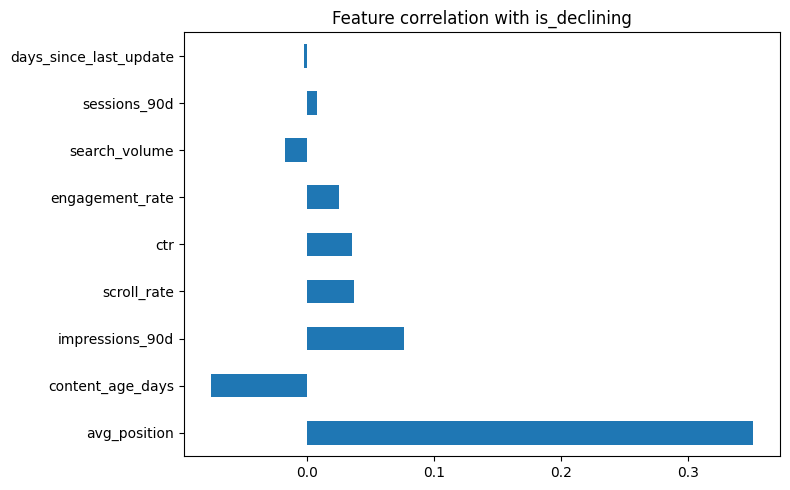

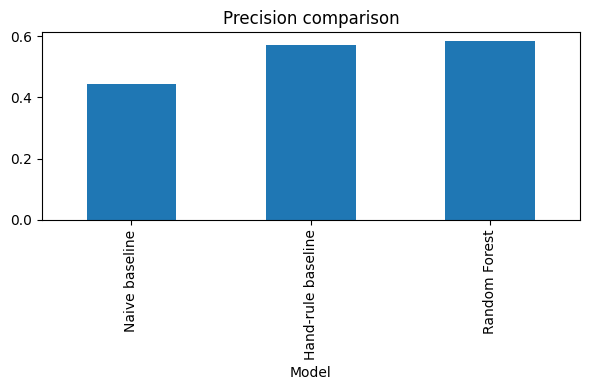

In [6]:
# This cell is for CODE (numbers, a query, a check).
# Write your text answer in the cell ABOVE this one — typing sentences here breaks Run All.
import matplotlib.pyplot as plt

corr.plot(kind="barh", figsize=(8,5), title="Feature correlation with is_declining")
plt.tight_layout()
plt.savefig("work/outputs/feature_correlation.png")
plt.show()

comparison = pd.DataFrame({
    "Model": ["Naive baseline", "Hand-rule baseline", "Random Forest"],
    "Precision": [0.445, 0.5723, 0.5835]
})
comparison.plot(x="Model", y="Precision", kind="bar", legend=False,
                 title="Precision comparison", figsize=(6,4))
plt.tight_layout()
plt.savefig("work/outputs/precision_comparison.png")
plt.show()

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.